# 03 - Released Key

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import pygame

plt.rcParams["figure.figsize"] = (20,6)

df = pd.read_parquet("/Users/Ana/20250507_132315.parquet")

## Rutinas

In [20]:

# cuando key pasa de un valor > 0 a 0 → release
df["key_prev"] = df["key"].shift(1)

# Detectar presiones y liberaciones directamente
pressed_times = df[(df["key_prev"] == 0) & (df["key"] > 0)]["timestamp"].reset_index(drop=True)
df_released = df[(df["key_prev"] > 0) & (df["key"] == 0)][["timestamp", "key_prev"]].reset_index(drop=True)

# Lo he puesto opcional calcular cuánto mantienen presionada la tecla
df_released["press_time"] = pressed_times
df_released["duracion_ms"] = df_released["timestamp"] - df_released["press_time"]


df_released["key_prev"] = df_released["key_prev"].astype(int)
df_released["key_name"] = df_released["key_prev"].apply(pygame.key.name)

print(df_released)

       timestamp  key_prev     press_time  duracion_ms key_name
0  1746616978421        32  1746616978371           50    space
1  1746616981295       115  1746616981213           82        s
2  1746616984671       119  1746616984590           81        w
3  1746616987692       107  1746616987625           67        k
4  1746616990466       107  1746616990400           66        k
5  1746616994600       119  1746616994484          116        w


## Duración pulsación por tecla

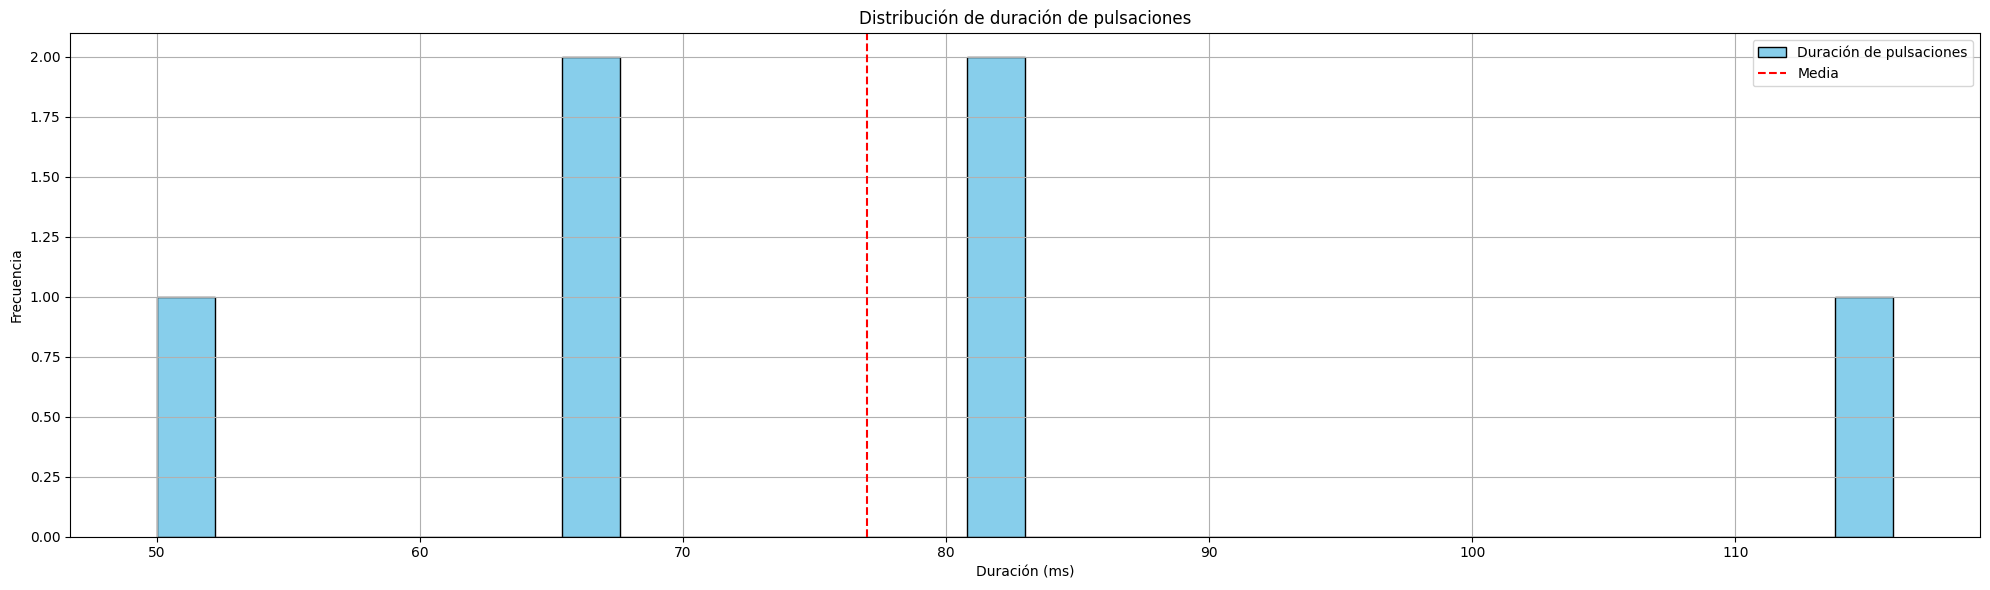

In [21]:
plt.hist(df_released["duracion_ms"], bins=30, color="skyblue", edgecolor="black", label="Duración de pulsaciones")
plt.axvline(df_released["duracion_ms"].mean(), color="r", linestyle="--", label="Media")
plt.xlabel("Duración (ms)")
plt.ylabel("Frecuencia")
plt.title("Distribución de duración de pulsaciones")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Si la mayoría de las pulsaciones duran menos de 200 ms → el usuario teclea rápido.
# Si hay pulsaciones largas o picos raros → puede indicar errores, pausas, o que mantuvo teclas apretadas.

## Línea temporal de pulsaciones

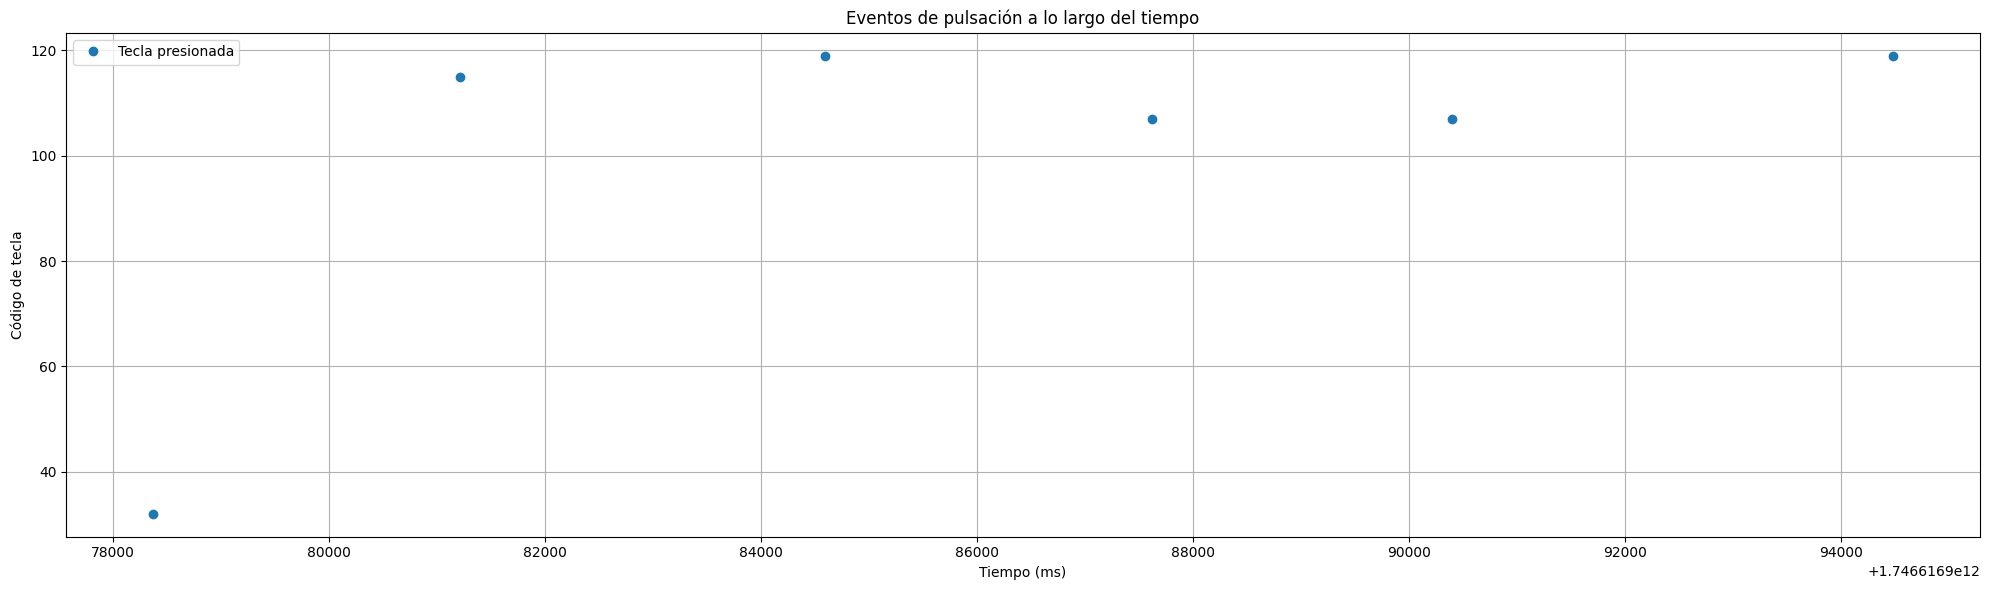

In [22]:
plt.plot(df_released["press_time"], df_released["key_prev"], 'o', label="Tecla presionada")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Código de tecla")
plt.title("Eventos de pulsación a lo largo del tiempo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Duración media de pulsaciones por tecla

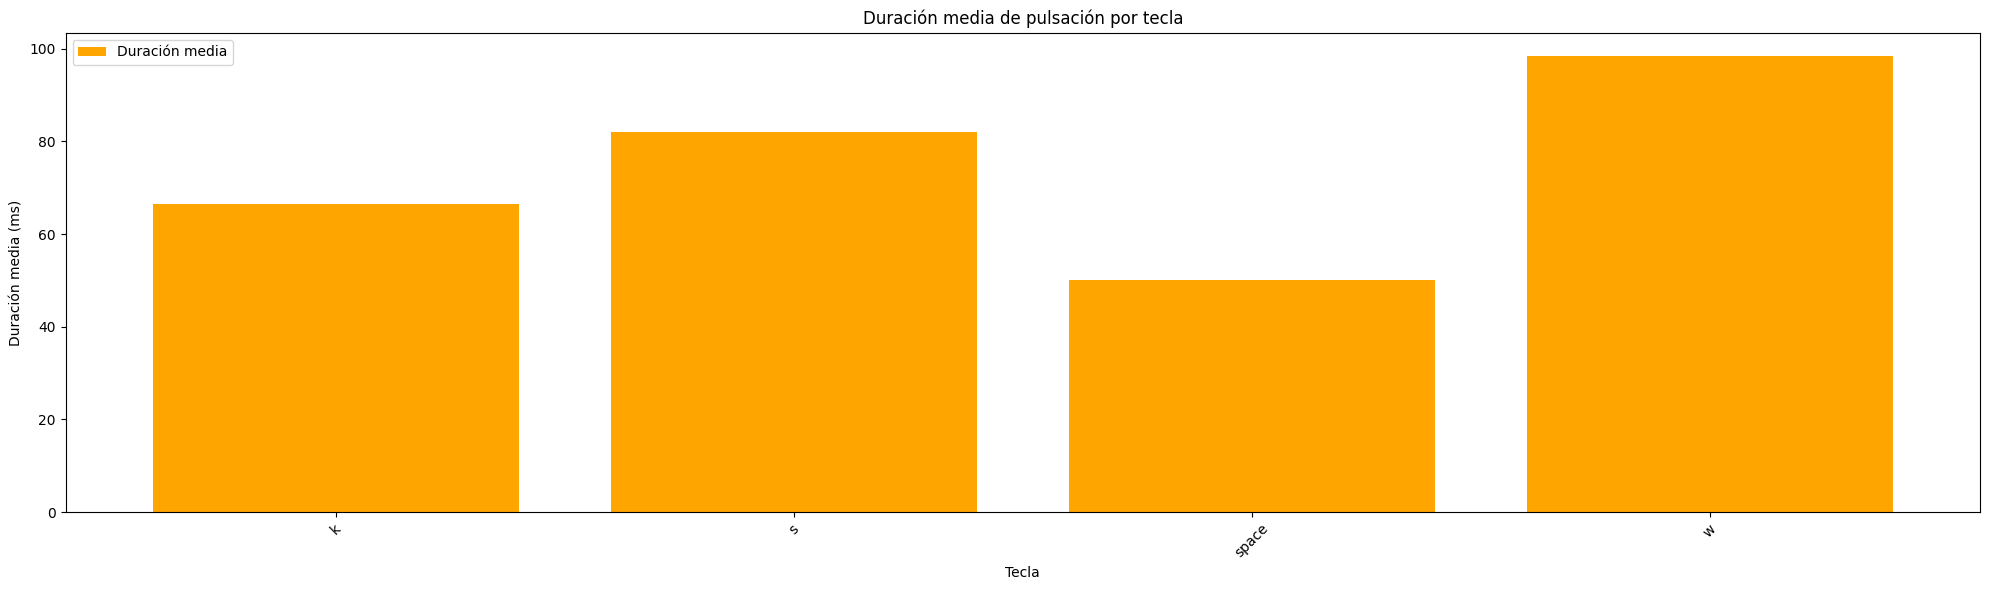

In [23]:
duracion_media = df_released.groupby("key_name")["duracion_ms"].mean()


plt.bar(duracion_media.index, duracion_media.values, color="orange", label="Duración media")
plt.xlabel("Tecla")
plt.ylabel("Duración media (ms)")
plt.title("Duración media de pulsación por tecla")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Frecuencia de teclas presionadas

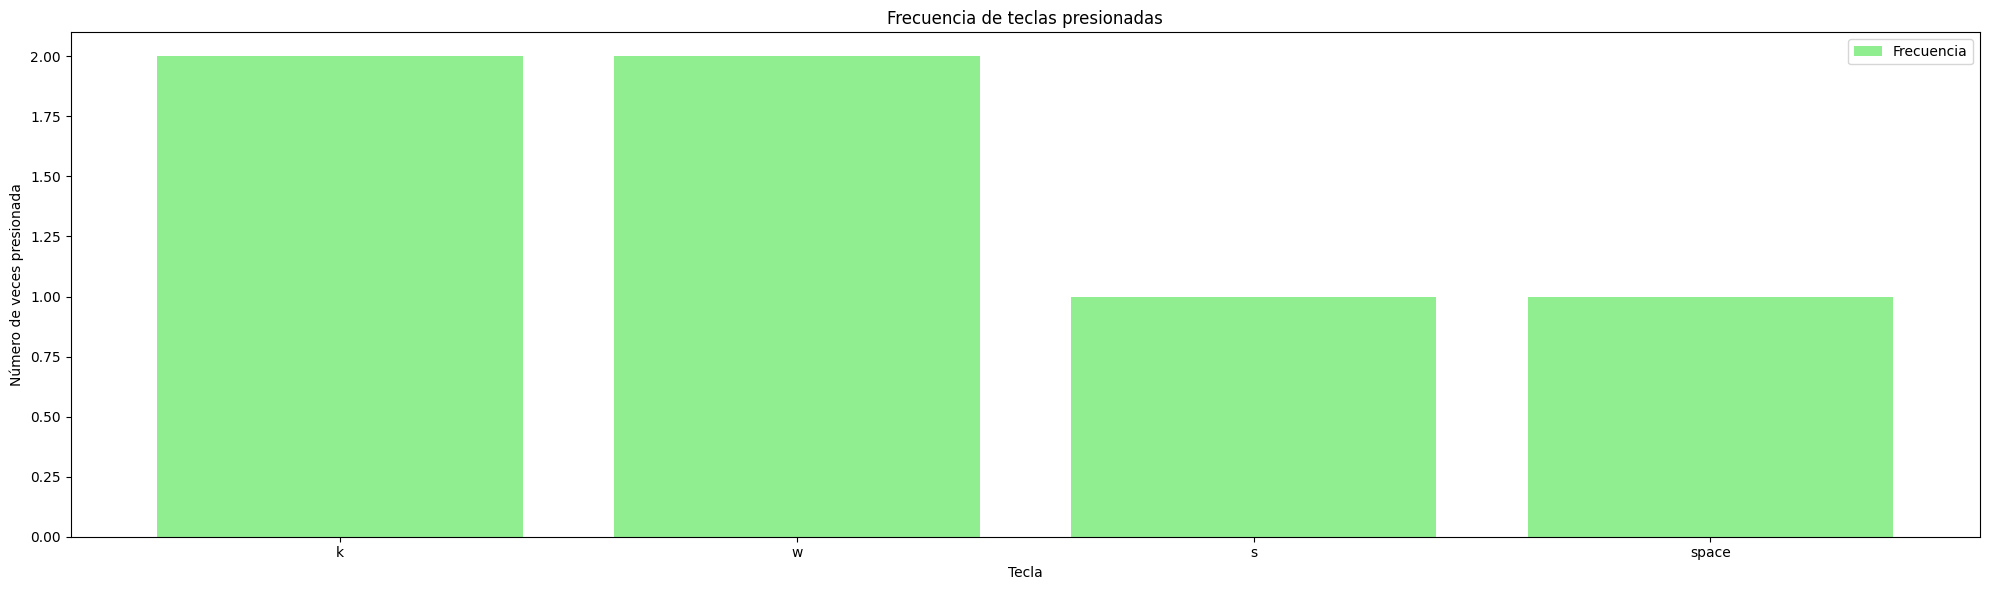

In [ ]:
key_counts = df_released["key_name"].value_counts()


plt.bar(key_counts.index, key_counts.values, color="lightgreen", label="Frecuencia")
plt.xlabel("Tecla")
plt.ylabel("Número de veces presionada")
plt.title("Frecuencia de teclas presionadas")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
